In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

loading red_fox image folder...
*completed red_fox folder*
loading raccoon image folder...
*completed raccoon folder*
loading mountain_beaver image folder...
*completed mountain_beaver folder*
loading deer image folder...
*completed deer folder*
loading coyote image folder...
*completed coyote folder*
loading cats image folder...
*completed cats folder*
loading dogs image folder...
*completed dogs folder*
loading squirrel image folder...
*completed squirrel folder*
loading rabbit image folder...
*completed rabbit folder*


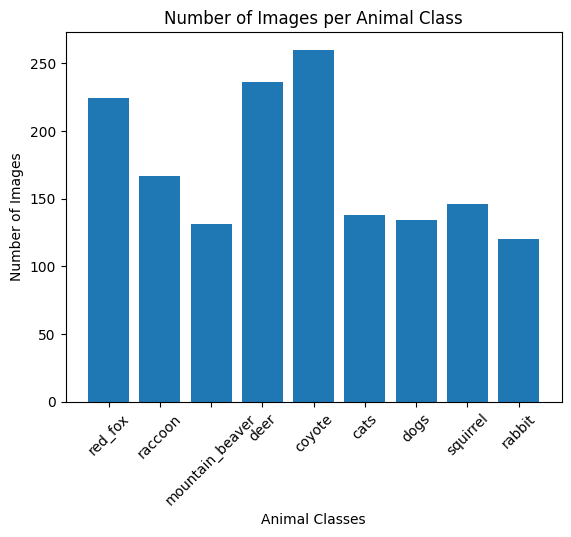

In [3]:
### Image Loading and Resizing, Data metrics
animals = ['red_fox','raccoon','mountain_beaver','deer','coyote', 'cats', 'dogs', 'squirrel', 'rabbit']
img_data_arr = []
class_label_arr = []

datadir = r"C:\Users\Using Janani\Downloads\gardenPal_imgset"
feature_shape = () # variable to print out the feature array's size
num_img_per_animal = [] # array holding number of images per folder
for i in animals:
    print(f"loading {i} image folder...")
    path = os.path.join(datadir, i)
    num_img_per_animal.append(len(os.listdir(path))) # append number of images in each animal folder
    for img_file in os.listdir(path):
        img_path = os.path.join(path, img_file)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb") # loads image, sizes it to 224x224, and forces it to be rgb (handles a couple of transparent images)
        img_array = tf.keras.preprocessing.image.img_to_array(img) # Turns the image into a numpy array
        img_data_arr.append(img_array) # appends single image array to total image array
        class_label_arr.append(animals.index(i)) # appends that image's class to total class array
    print(f"*completed {i} folder*")

# Convert to numpy
img_data = np.array(img_data_arr, dtype="float32")
class_labels = np.array(class_label_arr)


# Bar chart of Images per Animal Class
plt.bar(animals, num_img_per_animal)
plt.xlabel('Animal Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.title('Number of Images per Animal Class')
plt.show()


In [4]:
# using MobileNetV2 as a feature extractor and do include_top = False so it only returns 1280 size feature array
cnn_mobileV2 = MobileNetV2(weights="imagenet", input_shape = (224, 224, 3), include_top=False)
cnn_mobileV2.trainable = False  # freeze model so it doesn't use different weights for the train/test

# split train, test, and validation data before model training
X_train, X_temp, y_train, y_temp = train_test_split(img_data, class_labels, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

In [5]:
# Build Model: Data Augmentation to include random and realistic transformations to data, Uses MobileNetV2 for transfer learning
#              and preprocessing, and custom layers with reLU and softmax activation functions.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), #layers.RandomZoom(0.1),
]) # Artificially increases the diversity and size of the training dataset by applying random, realistic transformations

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs) # Each training image gets randomly modified, each epoch gets slightly different version
x = preprocess_input(x) # Converts pixel values from [0, 255] → [-1, 1] because MobileNetV2 uses this format
x = cnn_mobileV2(x, training=False) # Detects edges, textures, shapes, patterns, returns feature map (7 x 7 x 1280 size)

x = layers.GlobalAveragePooling2D()(x) # Flattens to 1280 array
x = layers.Dense(128, activation='relu')(x) # learns patterns in this dataset regarding each animal class
x = layers.Dropout(0.3)(x) # randomly turns off 30% of neurons to prevent overfitting
output = layers.Dense(len(animals), activation='softmax')(x) # labels the output as probabilities for each class

model = models.Model(inputs=inputs, outputs=output)


In [6]:
# Compile and train the model with training data
model.compile(
    optimizer='adam', # adam (adaptive moment estimation) optimizer
    loss='sparse_categorical_crossentropy', # (for 0-7 labels)
    metrics=['accuracy'] 
)

model.fit(x=X_train, y=y_train, epochs=10, validation_data = (X_val,y_val), batch_size=16)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 330ms/step - accuracy: 0.7355 - loss: 0.8872 - val_accuracy: 0.9356 - val_loss: 0.2475
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.8898 - loss: 0.3552 - val_accuracy: 0.9442 - val_loss: 0.1966
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.9183 - loss: 0.2661 - val_accuracy: 0.9313 - val_loss: 0.2087
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 308ms/step - accuracy: 0.9201 - loss: 0.2435 - val_accuracy: 0.9442 - val_loss: 0.1786
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 301ms/step - accuracy: 0.9100 - loss: 0.3081 - val_accuracy: 0.9528 - val_loss: 0.1650
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 301ms/step - accuracy: 0.9495 - loss: 0.1480 - val_accuracy: 0.9270 - val_loss: 0.1907
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 310ms/step - accuracy: 0.9522 - loss: 0.1382 - val_accuracy: 0.9657 - val_loss: 0.1462
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 300ms/step - accuracy: 0.9385 - loss: 0.1734 - val_accu

In [12]:
# Retrains model but unfreezes top layers while keeping earlier layers frozen to finetune the model to the weights in the dataset
cnn_mobileV2.trainable = True

class_weight = {
    0: 1.0,  # red_fox
    1: 1.0,  # raccoon
    2: 1.0,  # mountain_beaver
    3: 2.5,  # deer (increase weight)
    4: 1.0,  # coyote
    5: 1.1,  # cats
    6: 1.1,  # dogs
    7: 1.0,  # squirrel
    8: 2.5   # rabbit (increase weight)
}

# Freeze lower layers, unfreeze top ones
for layer in cnn_mobileV2.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x=X_train, y=y_train, epochs=15, validation_data = (X_val,y_val), class_weight=class_weight)

Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 874ms/step - accuracy: 0.9642 - loss: 0.1272 - val_accuracy: 0.9528 - val_loss: 0.1392
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 798ms/step - accuracy: 0.9688 - loss: 0.1239 - val_accuracy: 0.9442 - val_loss: 0.1379
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 801ms/step - accuracy: 0.9770 - loss: 0.0973 - val_accuracy: 0.9442 - val_loss: 0.1362
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 794ms/step - accuracy: 0.9587 - loss: 0.1476 - val_accuracy: 0.9485 - val_loss: 0.1390
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 801ms/step - accuracy: 0.9826 - loss: 0.0914 - val_accuracy: 0.9442 - val_loss: 0.1408
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 803ms/step - accuracy: 0.9743 - loss: 0.1022 - val_accuracy: 0.9442 - val_loss: 0.1416
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 848ms/step - accuracy: 0.9807 - loss: 0.0854 - val_accuracy: 0.9442 - val_loss: 0.1415
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 837ms/step - accuracy: 0.9743 - loss: 0.1099 - val_accu

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 483ms/step - accuracy: 0.9530 - loss: 0.1416
Model R-squared score on test data: [0.14159338176250458, 0.9529914259910583]
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 705ms/step
Test set's F1 Score: 0.9451551124622402
Test set's Accuracy: 0.9529914529914529


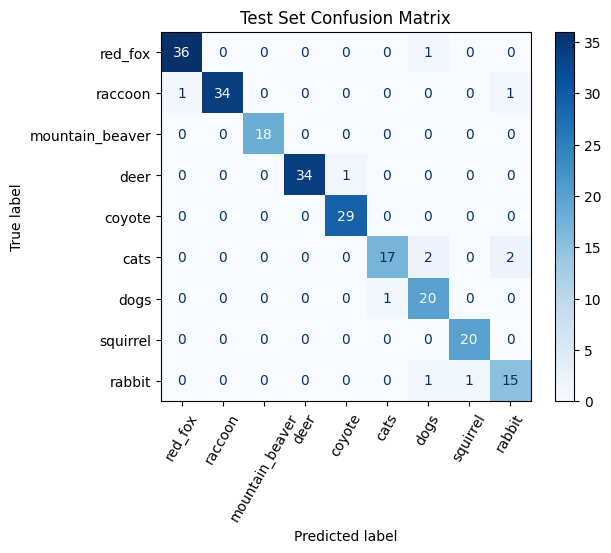

In [13]:
score = model.evaluate(X_test, y_test)
print(f"Model R-squared score on test data: {score}")

# Make predictions on the test data
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
print("Test set's F1 Score:", f1_score(y_test, y_pred, average="macro"))
print("Test set's Accuracy:", accuracy_score(y_test, y_pred))

confusion_test = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_test, display_labels=animals)
disp.plot(cmap="Blues", xticks_rotation=60)
plt.title("Test Set Confusion Matrix")
plt.show()

In [15]:
### Testing on backyard images of animals
img_data_arr_TEST = []


datadir = r"C:\Users\Using Janani\Downloads\gardenPal_testset"
feature_shape = ()
for img_file in os.listdir(datadir):
    img_path = os.path.join(datadir, img_file)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb")
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_data_arr_TEST.append(img_array)


img_data = np.array(img_data_arr_TEST, dtype="float32")
class_labels = np.array([6, 5, 7, 7, 0, 1, 2, 3, 4])
# ['red_fox 0','raccoon 1','mountain_beaver 2','deer 3','coyote 4', 'cats 5', 'dogs 6', 'squirrel 7', rabbit '8']

predictions = model.predict(img_data)
y_predict_TEST = np.argmax(predictions, axis=1)
print(y_predict_TEST)
print("New Test set's F1 Score:", f1_score(class_labels, y_predict_TEST, average="macro"))
print("New Test set's Accuracy:", accuracy_score(class_labels, y_predict_TEST))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
[8 8 7 7 0 8 2 3 4]
New Test set's F1 Score: 0.5555555555555556
New Test set's Accuracy: 0.6666666666666666


In [1]:
### Sending Model via scp over to Raspberry PI

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gardenPal_animal_model.tflite", "wb") as f:
    f.write(tflite_model)


NameError: name 'tf' is not defined

In [12]:
import cv2
import numpy as np

# Load model
net = cv2.dnn.readNetFromCaffe(
    "MobileNetSSD_deploy.prototxt",
    "MobileNetSSD_deploy.caffemodel"
)

# Class labels MobileNet was trained on
CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
           "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           "dog", "horse", "motorbike", "person", "pottedplant",
           "sheep", "sofa", "train", "tvmonitor"]

def detect_human(image_path):
    frame = cv2.imread(image_path)

    if frame is None:
        print("Error: Could not load image")
        return

    h, w = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.5:
            idx = int(detections[0, 0, i, 1])

            if CLASSES[idx] == "person":
                return True  # Human found

    return False  # No human

datadir_human = r"C:\Users\Using Janani\Downloads\human1.jpg"
datadir_dog = r"C:\Users\Using Janani\Downloads\gardenPal_testset\img1_dog.jpg"
print(detect_human(datadir_human))
print(detect_human(datadir_dog))

True
False
